Project Objectives
Google Play Store Apps
https://www.kaggle.com/datasets/lava18/google-play-store-apps/data

1. Category Popularity (Counts + Installs)

2. Ratings vs Installs (Relationship Analysis)

3. Free vs Paid App Performance

4. Price, Size, and App Performance (Paid Apps Only)

5. Content Rating (Age Group) Differences



In [32]:
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [81]:
# !ls "/content/drive/MyDrive"


In [34]:
# df = pd.read_csv('/content/drive/MyDrive/datasets/googleplaystore.csv')


In [35]:
df = pd.read_csv("googleplaystore.csv")


df = df.dropna(subset=["Category", "Installs"])


df["Installs"] = df["Installs"].str.replace(",", "")
df["Installs"] = df["Installs"].str.replace("+", "")
df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")


df = df.dropna(subset=["Installs"])


df = df.drop_duplicates()


In [36]:
df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,10000.0,Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000.0,Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,5000000.0,Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,50000000.0,Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,100000.0,Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,5000.0,Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100.0,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,1000.0,Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,1000.0,Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10357 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10357 non-null  object 
 1   Category        10357 non-null  object 
 2   Rating          8892 non-null   float64
 3   Reviews         10357 non-null  object 
 4   Size            10357 non-null  object 
 5   Installs        10357 non-null  float64
 6   Type            10356 non-null  object 
 7   Price           10357 non-null  object 
 8   Content Rating  10357 non-null  object 
 9   Genres          10357 non-null  object 
 10  Last Updated    10357 non-null  object 
 11  Current Ver     10349 non-null  object 
 12  Android Ver     10355 non-null  object 
dtypes: float64(2), object(11)
memory usage: 1.4+ MB


In [38]:
df.describe()

,Rating,Installs
count,8892.000000,1.035700e+04
mean,4.187877,1.415776e+07
std,0.522377,8.023955e+07
min,1.000000,0.000000e+00
25%,4.000000,1.000000e+03
50%,4.300000,1.000000e+05
75%,4.500000,1.000000e+06
max,5.000000,1.000000e+09


In [39]:
df.isnull().sum()

,0
App,0
Category,0
Rating,1465
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,0
Genres,0


In [92]:
df['Category'].value_counts()

,count
Category,
FAMILY,1943
GAME,1121
TOOLS,843
BUSINESS,427
MEDICAL,408
PRODUCTIVITY,407
PERSONALIZATION,388
LIFESTYLE,373
COMMUNICATION,366


In [93]:
df['Installs'].value_counts()

,count
Installs,
1.000000e+06,1488
1.000000e+07,1132
1.000000e+05,1129
1.000000e+04,1033
1.000000e+03,890
1.000000e+02,710
5.000000e+06,683
5.000000e+05,517
5.000000e+04,474


In [40]:
category_df = df[["Category", "Installs"]]
category_df


,Category,Installs
0,ART_AND_DESIGN,10000.0
1,ART_AND_DESIGN,500000.0
2,ART_AND_DESIGN,5000000.0
3,ART_AND_DESIGN,50000000.0
4,ART_AND_DESIGN,100000.0
...,...,...
10836,FAMILY,5000.0
10837,FAMILY,100.0
10838,MEDICAL,1000.0
10839,BOOKS_AND_REFERENCE,1000.0


In [41]:
category_counts = category_df["Category"].value_counts()
print(category_counts.head())


Category
FAMILY      1943
GAME        1121
TOOLS        843
BUSINESS     427
MEDICAL      408
Name: count, dtype: int64


In [42]:
category_installs = (
    category_df.groupby("Category")["Installs"]
          .sum()
          .sort_values(ascending=False)
)

print(category_installs.head())


Category
GAME             3.154402e+10
COMMUNICATION    2.415228e+10
SOCIAL           1.251387e+10
PRODUCTIVITY     1.246309e+10
TOOLS            1.145277e+10
Name: Installs, dtype: float64


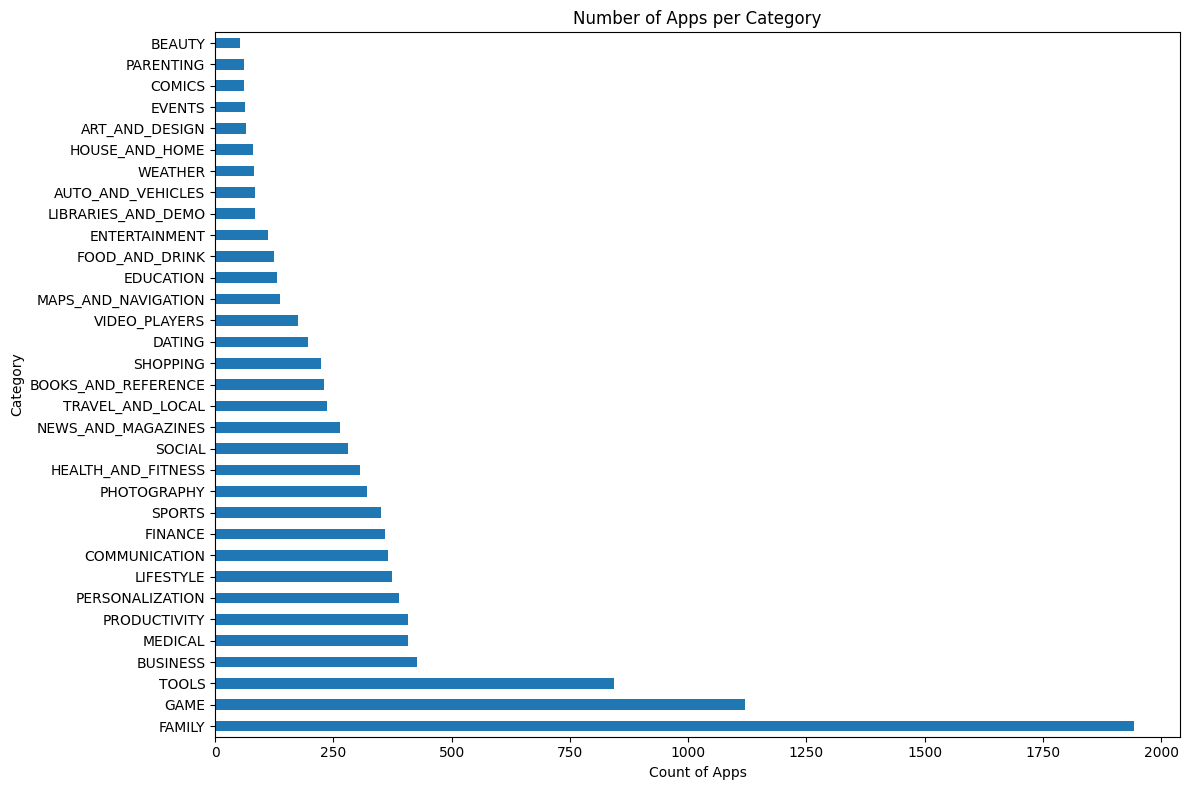

In [43]:
plt.figure(figsize=(12,8))
category_counts.plot(kind="barh")

plt.title("Number of Apps per Category")
plt.ylabel("Category")
plt.xlabel("Count of Apps")

plt.tight_layout()
plt.show()




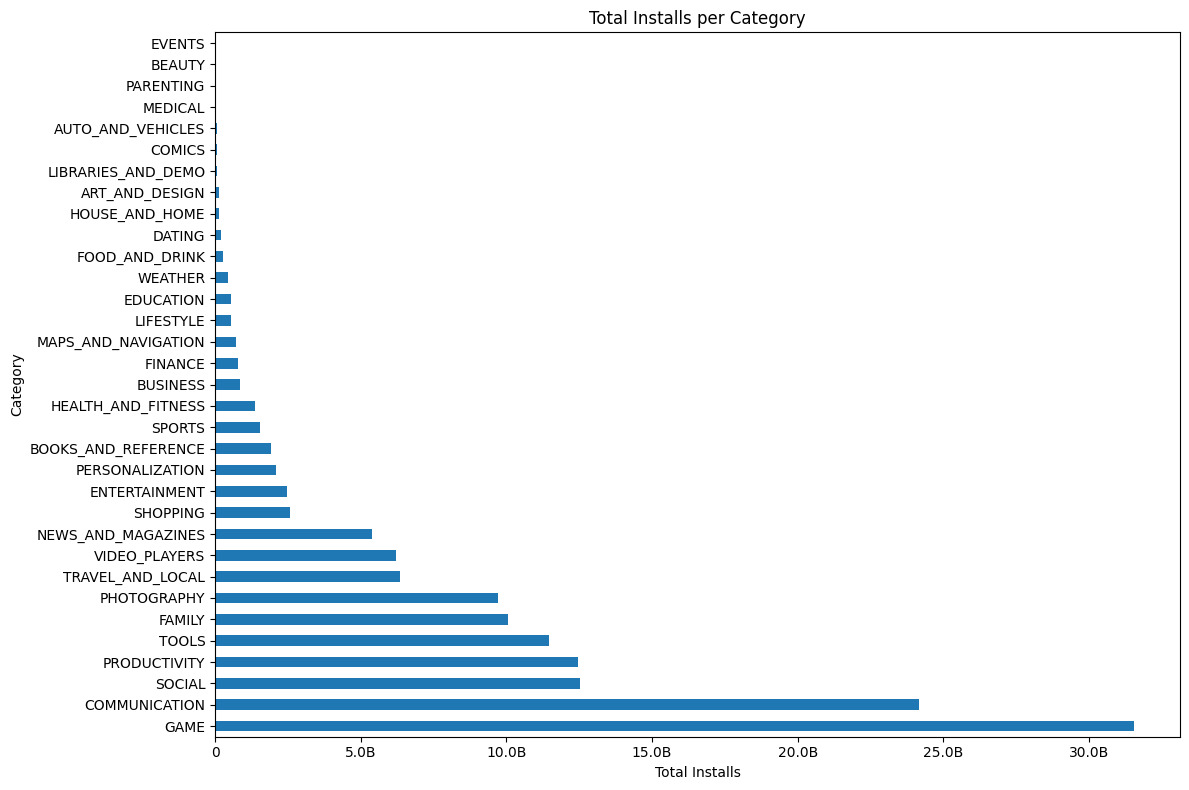

In [44]:
# plt.figure(figsize=(12,6))
# category_installs.plot(kind="bar")
# plt.title("Total Installs per Category")
# plt.xlabel("Category")
# plt.ylabel("Total Installs")
# plt.xticks(rotation=90)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(12,6))
# category_installs.plot(kind="bar")

# plt.title("Total Installs per Category")
# plt.xlabel("Category")
# plt.ylabel("Total Installs")   # ← unit added here

# plt.xticks(rotation=90)
# plt.tight_layout()
# plt.show()



def format_installs(x, pos):
    if x >= 1_000_000_000:
        return f"{x/1_000_000_000:.1f}B"   # Billions
    elif x >= 1_000_000:
        return f"{x/1_000_000:.1f}M"       # Millions
    else:
        return f"{int(x)}"

plt.figure(figsize=(12,8))
ax = category_installs.plot(kind="barh")

ax.set_title("Total Installs per Category")
ax.set_ylabel("Category")         # flipped
ax.set_xlabel("Total Installs")   # flipped

ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_installs))

plt.tight_layout()
plt.show()



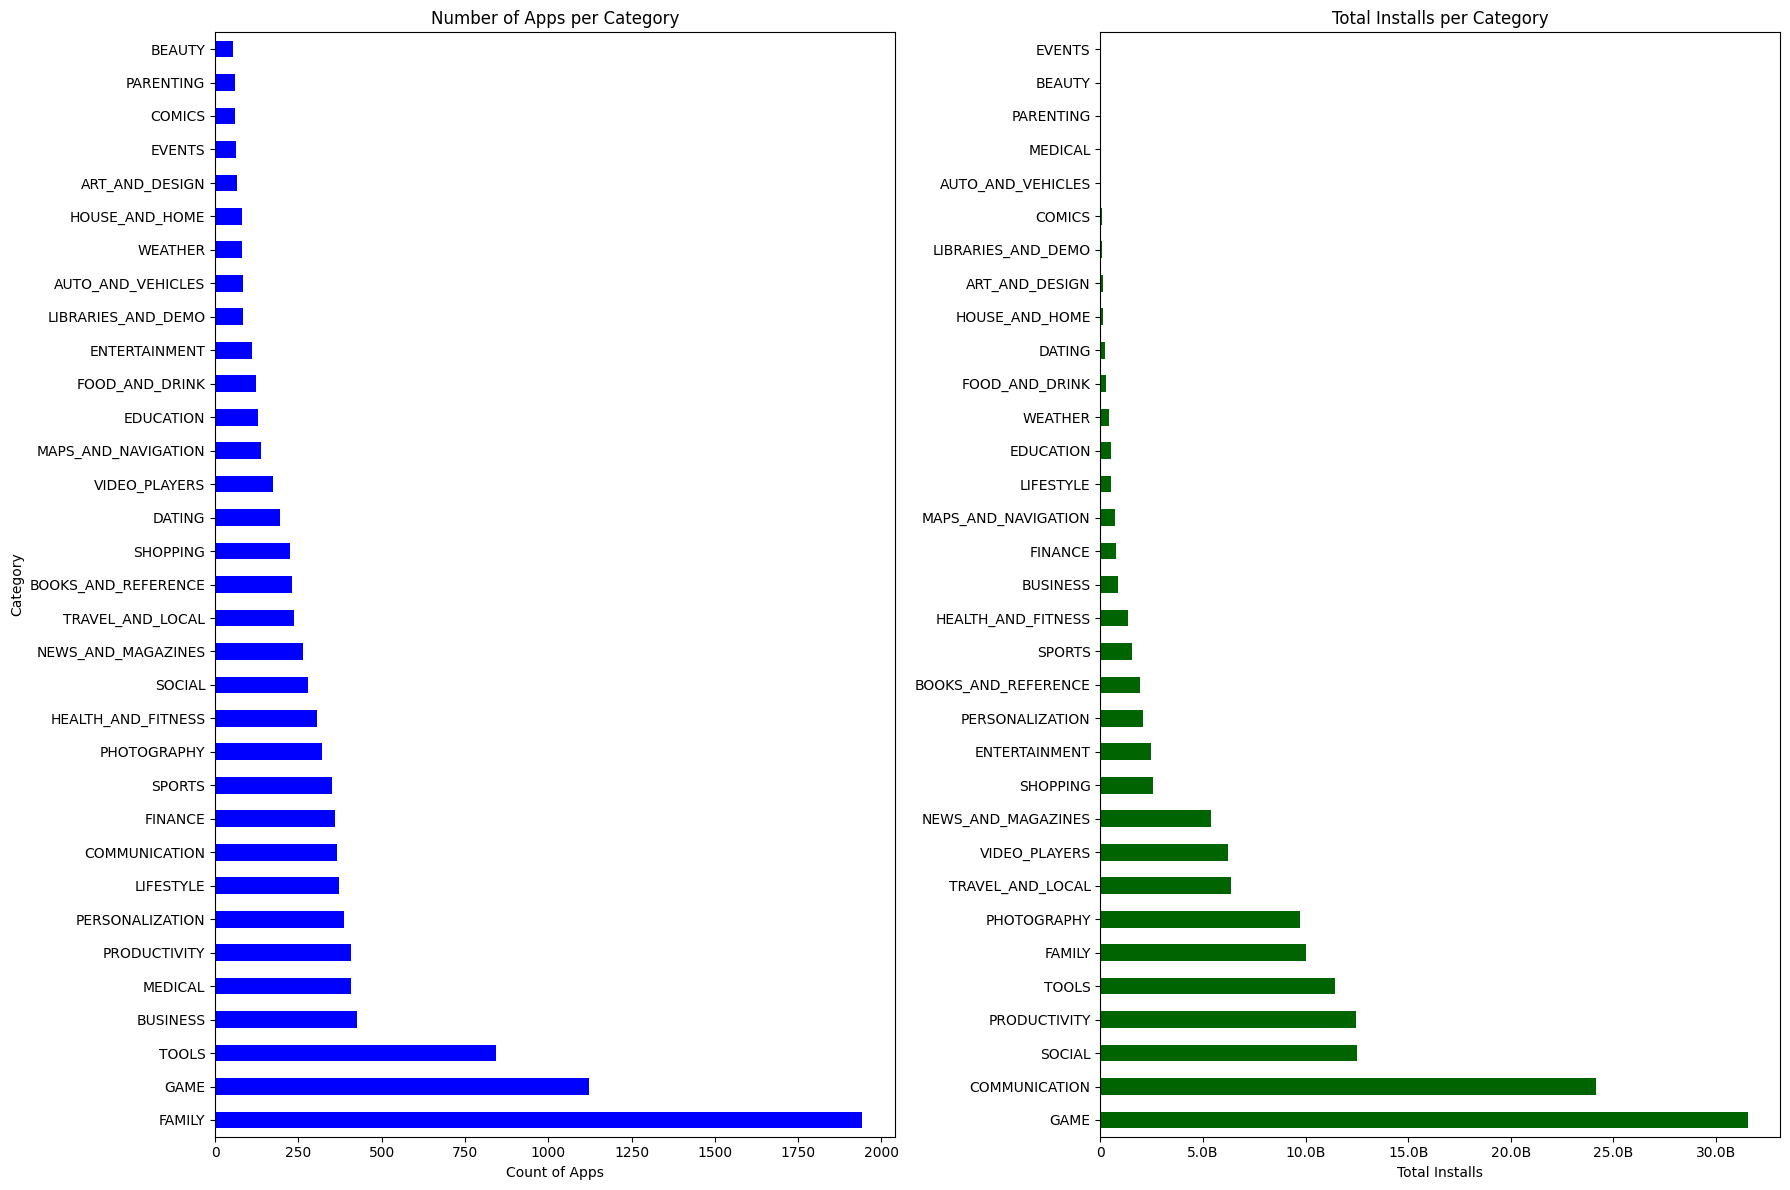

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(18, 12))


category_counts.sort_values(ascending=False).plot(kind="barh", ax=axes[0], color="blue")
axes[0].set_title("Number of Apps per Category")
axes[0].set_xlabel("Count of Apps")
axes[0].set_ylabel("Category")


category_installs.sort_values(ascending=False).plot(kind="barh", ax=axes[1], color="darkgreen")
axes[1].set_title("Total Installs per Category")
axes[1].set_xlabel("Total Installs")
axes[1].set_ylabel("")

axes[1].xaxis.set_major_formatter(ticker.FuncFormatter(format_installs))

plt.tight_layout()
plt.show()

In [45]:
for p in ax.patches:
    value = p.get_height()
    if value >= 1_000_000_000:
        label = f"{value/1_000_000_000:.1f}B"
    elif value >= 1_000_000:
        label = f"{value/1_000_000:.1f}M"
    else:
        label = str(int(value))

    ax.annotate(label,
                (p.get_x() + p.get_width()/2, value),
                ha='center', va='bottom', fontsize=8)


In [46]:
df["Installs"] = df["Installs"].astype(str)


In [47]:
df["Installs"] = df["Installs"].str.replace(",", "")
df["Installs"] = df["Installs"].str.replace("+", "")


In [48]:
df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")


In [49]:
df["Installs"] = (
    df["Installs"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)

df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")


In [50]:
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")
avg_rating = df["Rating"].mean()
df["Rating"] = df["Rating"].fillna(avg_rating)


In [51]:
df = df.dropna(subset=["Installs"])


In [52]:
ratings_df = df[["Rating", "Installs"]]
ratings_df

,Rating,Installs
0,4.100000,10000.0
1,3.900000,500000.0
2,4.700000,5000000.0
3,4.500000,50000000.0
4,4.300000,100000.0
...,...,...
10836,4.500000,5000.0
10837,5.000000,100.0
10838,4.187877,1000.0
10839,4.500000,1000.0


In [53]:
# plt.figure(figsize=(8,6))
# plt.scatter(ratings_df["Installs"], ratings_df["Rating"], s=10, alpha=0.4)

# plt.xscale("log")  # ← THIS IS IMPORTANT
# plt.xlabel("Installs (log scale)")
# plt.ylabel("Rating")
# plt.title("Ratings vs Installs")
# plt.show()
bins = [0, 10000, 100000, 1000000, 10000000, 100000000, 10000000000]
labels = ["0-10K", "10K-100K", "100K-1M", "1M-10M", "10M-100M", "100M+"]

df["Install_Group"] = pd.cut(df["Installs"], bins=bins, labels=labels)


In [54]:
avg_rating_group = df.groupby("Install_Group")["Rating"].mean()
avg_rating_group


/tmp/ipython-input-3853422759.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_rating_group = df.groupby("Install_Group")["Rating"].mean()


,Rating
Install_Group,
0-10K,4.138060
10K-100K,4.096397
100K-1M,4.207014
1M-10M,4.285675
10M-100M,4.382995
100M+,4.309091


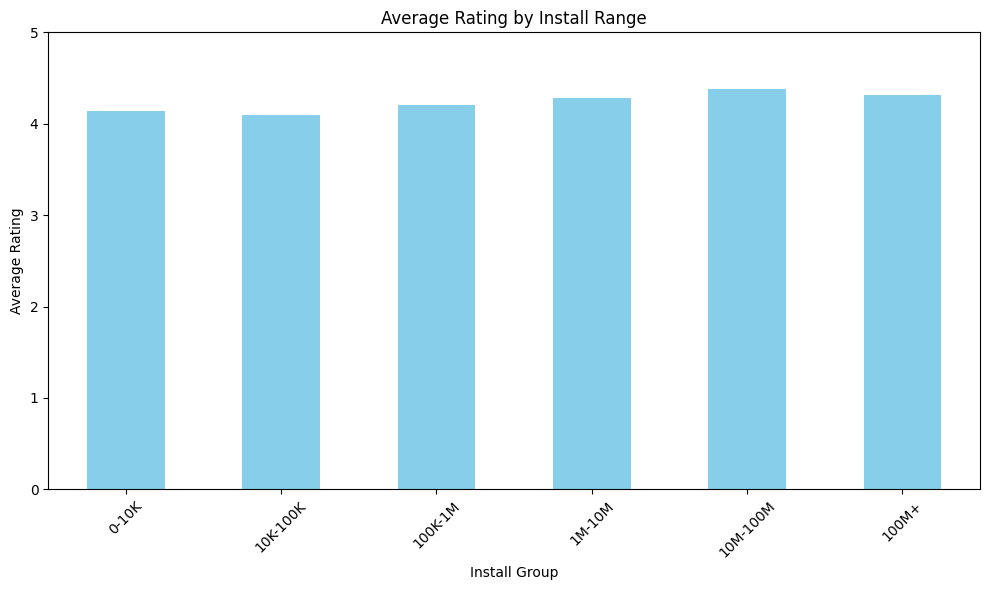

In [55]:
plt.figure(figsize=(10,6))
avg_rating_group.plot(kind="bar", color="skyblue")

plt.title("Average Rating by Install Range")
plt.xlabel("Install Group")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.ylim(0, 5)   # ratings go 0–5
plt.tight_layout()
plt.show()


In [56]:
# objective 3

In [57]:
free_apps = df[df["Type"] == "Free"]
paid_apps = df[df["Type"] == "Paid"]


In [58]:
# free_apps.shape, paid_apps.shape


In [59]:
avg_free_rating = free_apps["Rating"].mean()
avg_paid_rating = paid_apps["Rating"].mean()


In [60]:
free = df[df["Type"] == "Free"]
paid = df[df["Type"] == "Paid"]


In [61]:
# free_filtered = free[free["Installs"] <= 500_000_000]
# paid_filtered = paid[paid["Installs"] <= 500_000_000]


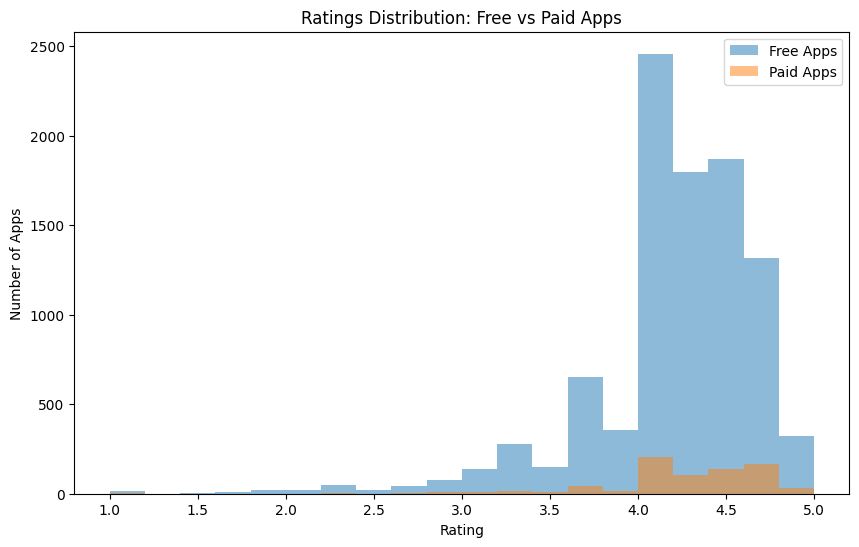

In [62]:
plt.figure(figsize=(10,6))

plt.hist(free["Rating"], bins=20, alpha=0.5, label="Free Apps")
plt.hist(paid["Rating"], bins=20, alpha=0.5, label="Paid Apps")

plt.title("Ratings Distribution: Free vs Paid Apps")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")
plt.legend()
plt.show()



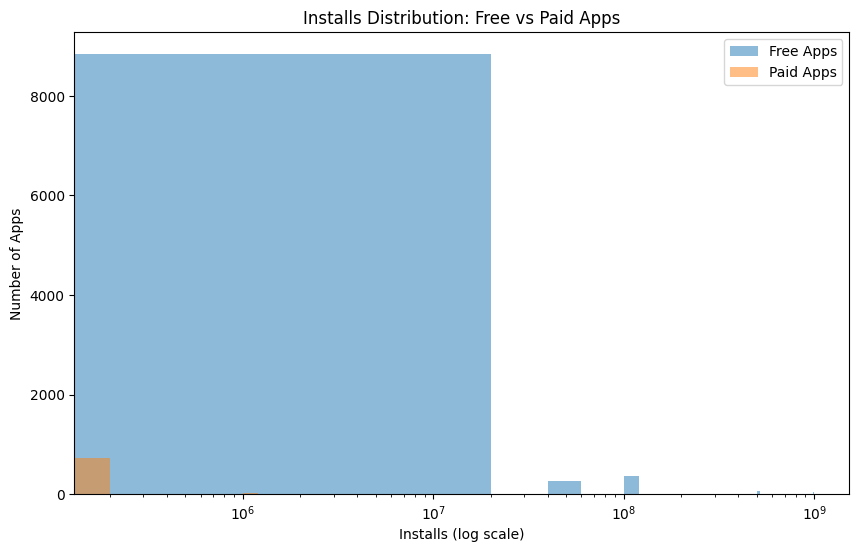

In [63]:
plt.figure(figsize=(10,6))

plt.hist(free["Installs"], bins=50, alpha=0.5, label="Free Apps")
plt.hist(paid["Installs"], bins=50, alpha=0.5, label="Paid Apps")

plt.xscale("log")
plt.title("Installs Distribution: Free vs Paid Apps")
plt.xlabel("Installs (log scale)")
plt.ylabel("Number of Apps")
plt.legend()
plt.show()


In [64]:
# objective 4
paid = df[df["Type"] == "Paid"].copy()


In [65]:
paid["Price"] = paid["Price"].astype(str).str.replace("$", "", regex=False)
paid["Price"] = paid["Price"].astype(float)


In [66]:
def convert_size(value):
    value = str(value)

    if "M" in value:
        return float(value.replace("M", ""))
    elif "k" in value or "K" in value:
        return float(value.replace("k", "").replace("K","")) / 1000
    elif "G" in value:
        return float(value.replace("G", "")) * 1000
    else:
        return None

paid["Size_MB"] = paid["Size"].apply(convert_size)


In [67]:
paid["Size_MB"] = paid["Size_MB"].fillna(paid["Size_MB"].mean())


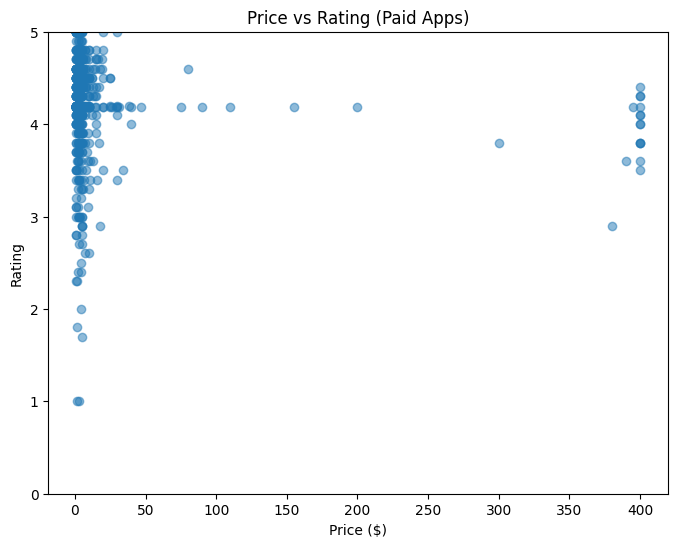

In [68]:
plt.figure(figsize=(8,6))
plt.scatter(paid["Price"], paid["Rating"], alpha=0.5)

plt.title("Price vs Rating (Paid Apps)")
plt.xlabel("Price ($)")
plt.ylabel("Rating")
plt.ylim(0, 5)
plt.show()


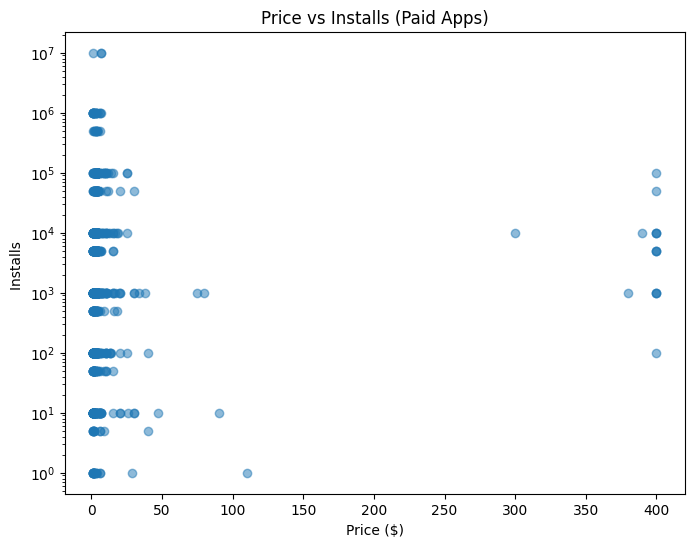

In [69]:
plt.figure(figsize=(8,6))
plt.scatter(paid["Price"], paid["Installs"], alpha=0.5)

plt.yscale("log")
plt.title("Price vs Installs (Paid Apps)")
plt.xlabel("Price ($)")
plt.ylabel("Installs ")
plt.show()


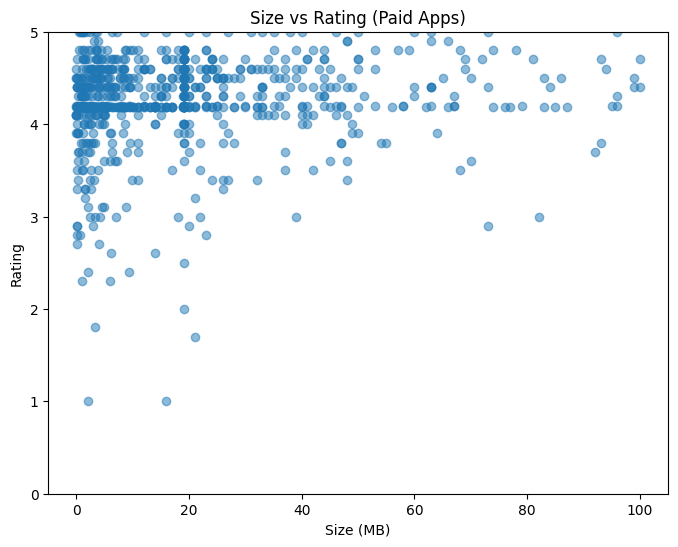

In [70]:
plt.figure(figsize=(8,6))
plt.scatter(paid["Size_MB"], paid["Rating"], alpha=0.5)

plt.title("Size vs Rating (Paid Apps)")
plt.xlabel("Size (MB)")
plt.ylabel("Rating")
plt.ylim(0, 5)
plt.show()


In [71]:
paid[["Price", "Rating", "Installs", "Size_MB"]].describe()


,Price,Rating,Installs,Size_MB
count,765.000000,765.000000,7.650000e+02,765.000000
mean,13.955556,4.246872,9.049135e+04,19.124602
std,58.406966,0.499334,6.458706e+05,21.076136
min,0.990000,1.000000,0.000000e+00,0.014000
25%,1.490000,4.187877,1.000000e+02,3.400000
50%,2.990000,4.300000,1.000000e+03,13.000000
75%,4.990000,4.600000,1.000000e+04,25.000000
max,400.000000,5.000000,1.000000e+07,100.000000


In [72]:
df["Content Rating"].value_counts()


,count
Content Rating,
Everyone,8382
Teen,1146
Mature 17+,447
Everyone 10+,377
Adults only 18+,3
Unrated,2


In [73]:
age_counts = df["Content Rating"].value_counts()
print(age_counts)

Content Rating
Everyone           8382
Teen               1146
Mature 17+          447
Everyone 10+        377
Adults only 18+       3
Unrated               2
Name: count, dtype: int64


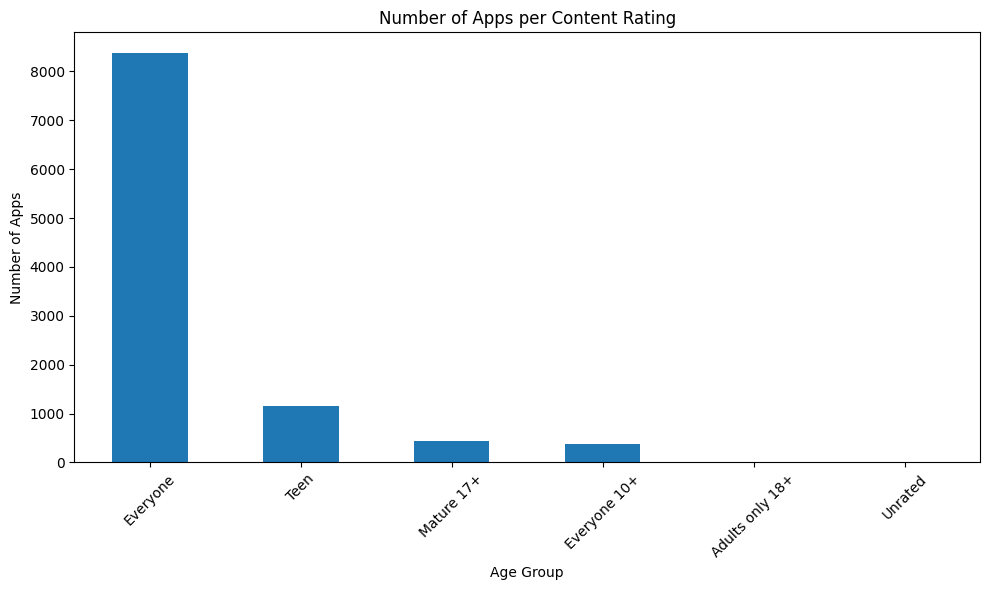

In [74]:
plt.figure(figsize=(10,6))
age_counts.plot(kind="bar")

plt.title("Number of Apps per Content Rating")
plt.xlabel("Age Group")
plt.ylabel("Number of Apps")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [75]:
avg_rating_by_age = df.groupby("Content Rating")["Rating"].mean()
print(avg_rating_by_age)


Content Rating
Adults only 18+    4.300000
Everyone           4.181901
Everyone 10+       4.251177
Mature 17+         4.129449
Teen               4.233330
Unrated            4.143938
Name: Rating, dtype: float64


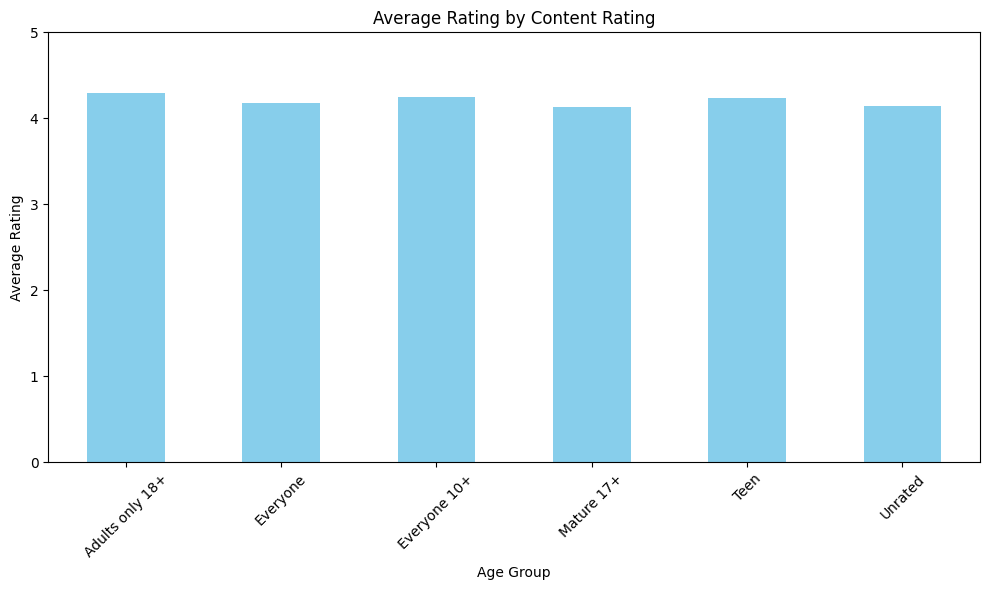

In [76]:
plt.figure(figsize=(10,6))
avg_rating_by_age.plot(kind="bar", color="skyblue")

plt.title("Average Rating by Content Rating")
plt.xlabel("Age Group")
plt.ylabel("Average Rating")
plt.ylim(0, 5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<Figure size 1000x600 with 0 Axes>

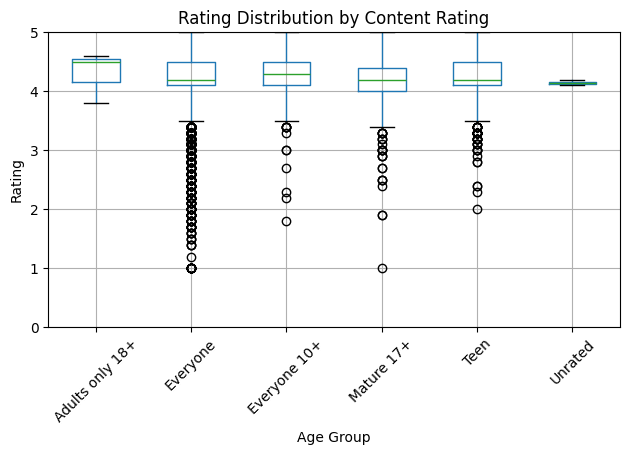

In [77]:
# plt.figure(figsize=(10,6))
# df.boxplot(column="Rating", by="Content Rating")

# plt.title("Rating Distribution by Content Rating")
# plt.suptitle("")      # removes extra title
# plt.xlabel("Age Group")
# plt.ylabel("Rating")
# plt.ylim(0, 5)
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()


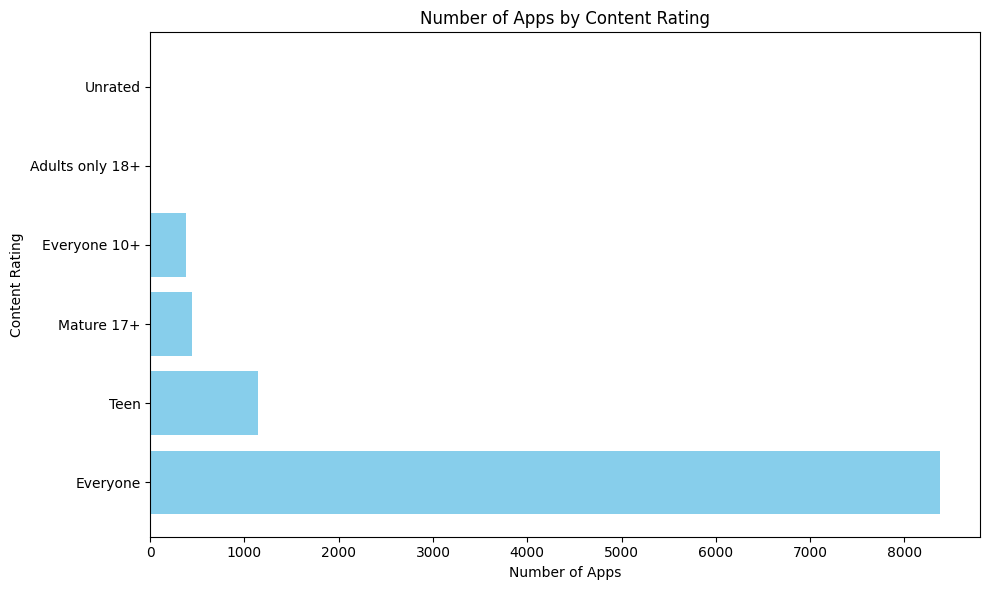

In [78]:
# plt.figure(figsize=(10,8))
# plt.pie(age_counts, autopct="%1.1f%%", startangle=90)
# plt.title("App Distribution by Content Rating")

# plt.legend(
#     age_counts.index,
#     loc="center left",
#     bbox_to_anchor=(1, 0.5)
# )
# plt.show()




# age_counts = df["Content Rating"].value_counts()

# plt.figure(figsize=(8,8))
# plt.pie(age_counts, labels=age_counts.index, autopct="%1.1f%%", startangle=90)
# plt.title("App Distribution by Content Rating")
# plt.show()


age_counts = df["Content Rating"].value_counts()

plt.figure(figsize=(10,6))
plt.barh(age_counts.index, age_counts.values, color="skyblue")

plt.title("Number of Apps by Content Rating")
plt.xlabel("Number of Apps")
plt.ylabel("Content Rating")
plt.tight_layout()
plt.show()



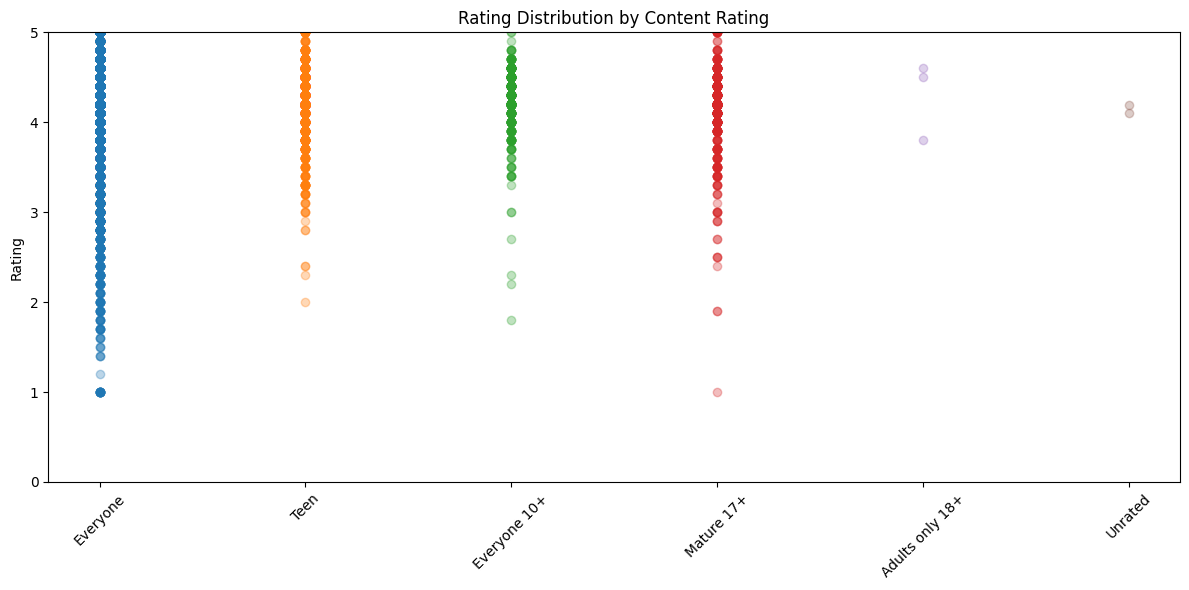

In [79]:
plt.figure(figsize=(12,6))

groups = df["Content Rating"].unique()

for i, group in enumerate(groups):
    ratings = df[df["Content Rating"] == group]["Rating"]
    plt.scatter([i] * len(ratings), ratings, alpha=0.3)

plt.xticks(range(len(groups)), groups, rotation=45)
plt.ylabel("Rating")
plt.title("Rating Distribution by Content Rating")
plt.ylim(0, 5)
plt.tight_layout()
plt.show()
